In [126]:
from pathlib import Path
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

In [127]:
COLORS = ["#4279a3", "#d57249"]

In [128]:
df = pd.read_csv("data/Occupancy_Estimation.csv")
print(f"{len(df):,} rows, {len(df.columns)} columns")
display(df.head())

10,129 rows, 19 columns


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [129]:
df = df.drop(columns=["Date", "Time"])
display(df.head())

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [130]:
df = df.sample(frac=1, random_state=1001).reset_index(drop=True)
display(df.head())

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,25.06,25.06,24.56,25.13,1,1,8,5,0.08,0.05,0.05,0.09,345,0.000000,0,0,0
1,25.06,25.06,24.63,25.31,6,6,32,22,0.08,0.05,0.06,0.09,350,0.000000,0,0,0
2,25.19,25.19,24.69,25.25,0,0,0,0,0.08,0.05,0.06,0.08,345,0.000000,0,0,0
3,25.63,25.63,25.25,25.81,0,0,0,0,0.07,0.04,0.06,0.06,505,-2.111538,0,0,0
4,25.13,25.06,24.56,25.13,5,5,26,18,0.08,0.04,0.06,0.09,345,0.000000,0,0,0


In [131]:
df["occupied"] = (df["Room_Occupancy_Count"] > 0).astype(int)
display(df.head())

df = df.drop(columns=["Room_Occupancy_Count"])
display(df.head())

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,occupied
0,25.06,25.06,24.56,25.13,1,1,8,5,0.08,0.05,0.05,0.09,345,0.000000,0,0,0,0
1,25.06,25.06,24.63,25.31,6,6,32,22,0.08,0.05,0.06,0.09,350,0.000000,0,0,0,0
2,25.19,25.19,24.69,25.25,0,0,0,0,0.08,0.05,0.06,0.08,345,0.000000,0,0,0,0
3,25.63,25.63,25.25,25.81,0,0,0,0,0.07,0.04,0.06,0.06,505,-2.111538,0,0,0,0
4,25.13,25.06,24.56,25.13,5,5,26,18,0.08,0.04,0.06,0.09,345,0.000000,0,0,0,0


,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,occupied
0,25.06,25.06,24.56,25.13,1,1,8,5,0.08,0.05,0.05,0.09,345,0.000000,0,0,0
1,25.06,25.06,24.63,25.31,6,6,32,22,0.08,0.05,0.06,0.09,350,0.000000,0,0,0
2,25.19,25.19,24.69,25.25,0,0,0,0,0.08,0.05,0.06,0.08,345,0.000000,0,0,0
3,25.63,25.63,25.25,25.81,0,0,0,0,0.07,0.04,0.06,0.06,505,-2.111538,0,0,0
4,25.13,25.06,24.56,25.13,5,5,26,18,0.08,0.04,0.06,0.09,345,0.000000,0,0,0


In [132]:
split = int(len(df) * 0.8)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print(f"Training: {len(train)} rows")
print(f"Test: {len(test)} rows")

Training: 8103 rows
Test: 2026 rows


In [133]:
features = ["S1_Temp", "S5_CO2"]

X_train = train[features].to_numpy()
y_train = train["occupied"].to_numpy()

X_test = test[features].to_numpy()
y_test = test["occupied"].to_numpy()

In [134]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

display(pd.DataFrame(X_train_std, columns=features).head())

print("Mean:", X_train_std.mean(axis=0))
print("Standard deviation:", X_train_std.std(axis=0))

,S1_Temp,S5_CO2
0,-1.122906,-0.578205
1,-1.122906,-0.553131
2,-0.752186,-0.578205
3,0.502561,0.224162
4,-0.923288,-0.578205


Mean: [ 1.75903829e-15 -4.20906471e-17]
Standard deviation: [1. 1.]


In [135]:
class Perceptron:
    def __init__(self, eta=0.01, n_iter=30, random_state=1001):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.errors_ = []
        self.error_rates_ = [np.mean(self.predict(X) != y)]

        for _ in range(self.n_iter):
            indices = rgen.permutation(len(y))
            X = X[indices]
            y = y[indices]
            epoch_errors = 0

            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                epoch_errors += int(update != 0.0)

            self.errors_.append(epoch_errors)
            self.error_rates_.append(np.mean(self.predict(X) != y))

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

In [136]:
ppn = Perceptron(eta=0.01, n_iter=30, random_state=1001)
ppn.fit(X_train_std, y_train)

print("Weights:", ppn.w_)
print("Bias:", ppn.b_)
print("Training accuracy:", f"{np.mean(ppn.predict(X_train_std) == y_train):.2%}")

Weights: [ 0.0607503  -0.00766184]
Bias: -0.03
Training accuracy: 88.78%


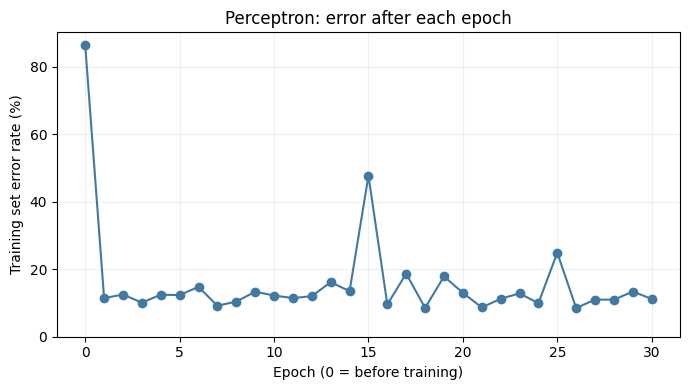

Before training: 86.36%
After epoch 1: 11.45%
After epoch 30: 11.22%


In [137]:
error_rates = np.array(ppn.error_rates_) * 100

plt.figure(figsize=(7, 4))
plt.plot(range(len(error_rates)), error_rates, marker="o", color=COLORS[0])
plt.xlabel("Epoch (0 = before training)")
plt.ylabel("Training set error rate (%)")
plt.title("Perceptron: error after each epoch")
plt.xticks(range(0, len(error_rates), 5))
plt.ylim(bottom=0)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Before training: {error_rates[0]:.2f}%")
print(f"After epoch 1: {error_rates[1]:.2f}%")
print(f"After epoch {ppn.n_iter}: {error_rates[-1]:.2f}%")

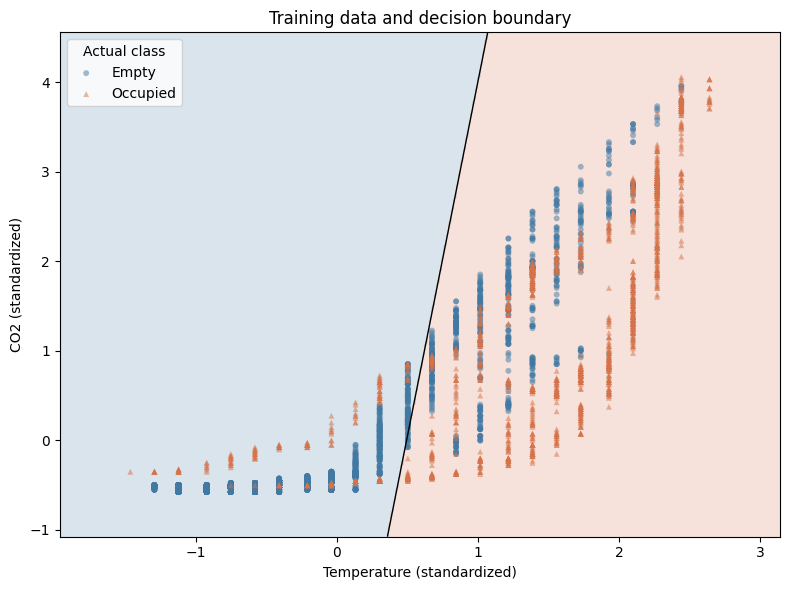

In [138]:
x1_min, x1_max = X_train_std[:, 0].min() - 0.5, X_train_std[:, 0].max() + 0.5
x2_min, x2_max = X_train_std[:, 1].min() - 0.5, X_train_std[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)
grid = np.column_stack((xx1.ravel(), xx2.ravel()))
Z = ppn.predict(grid).reshape(xx1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx1, xx2, Z, levels=[-0.5, 0.5, 1.5],
             alpha=0.2, cmap=ListedColormap(COLORS))
plt.contour(xx1, xx2, ppn.net_input(grid).reshape(xx1.shape),
            levels=[0], colors="black", linewidths=1)

for label, name, marker in [(0, "Empty", "o"), (1, "Occupied", "^")]:
    plt.scatter(X_train_std[y_train == label, 0],
                X_train_std[y_train == label, 1],
                c=COLORS[label], label=name, marker=marker,
                s=18, alpha=0.5, edgecolors="none")

plt.xlabel("Temperature (standardized)")
plt.ylabel("CO2 (standardized)")
plt.title("Training data and decision boundary")
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)
plt.legend(title="Actual class")
plt.tight_layout()
plt.show()

In [139]:
y_pred = ppn.predict(X_test_std)

tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))
tp = np.sum((y_test == 1) & (y_pred == 1))

print(f"Test samples: {len(y_test)}")
print(f"Test accuracy: {np.mean(y_pred == y_test):.2%}")
print(f"Always-empty accuracy: {np.mean(y_test == 0):.2%}")
print(f"Occupied recall: {tp / (tp + fn):.2%}")
print(f"Occupied precision: {tp / (tp + fp) if tp + fp else 0:.2%}")
print(f"False empty: {fn}")
print(f"False occupied: {fp}")

Test samples: 2026
Test accuracy: 88.55%
Always-empty accuracy: 81.69%
Occupied recall: 88.41%
Occupied precision: 63.44%
False empty: 43
False occupied: 189


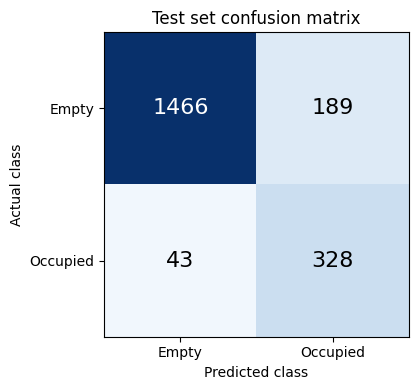

In [140]:
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues", vmin=0)
ax.set_xticks([0, 1], labels=["Empty", "Occupied"])
ax.set_yticks([0, 1], labels=["Empty", "Occupied"])
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Test set confusion matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=16)

plt.tight_layout()
plt.show()

In [141]:
features_all = train.columns.drop("occupied").tolist()
X_train_all = train[features_all].to_numpy()
X_test_all = test[features_all].to_numpy()

mean_all = X_train_all.mean(axis=0)
std_all = X_train_all.std(axis=0)
std_all[std_all == 0] = 1
X_train_all_std = (X_train_all - mean_all) / std_all
X_test_all_std = (X_test_all - mean_all) / std_all

print(f"Features: {len(features_all)}")
print(features_all)

Features: 16
['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR']


In [142]:
ppn_all = Perceptron(eta=0.01, n_iter=30, random_state=1001)
ppn_all.fit(X_train_all_std, y_train)
y_pred_all = ppn_all.predict(X_test_all_std)

comparison = []
for name, model, X, pred in [
    ("Temperature + CO2", ppn, X_train_std, y_pred),
    ("All 16 features", ppn_all, X_train_all_std, y_pred_all)
]:
    fp_i = np.sum((y_test == 0) & (pred == 1))
    fn_i = np.sum((y_test == 1) & (pred == 0))
    tp_i = np.sum((y_test == 1) & (pred == 1))
    comparison.append({
        "Model": name,
        "Train accuracy (%)": np.mean(model.predict(X) == y_train) * 100,
        "Test accuracy (%)": np.mean(pred == y_test) * 100,
        "Occupied recall (%)": tp_i / (tp_i + fn_i) * 100,
        "Occupied precision (%)": tp_i / (tp_i + fp_i) * 100 if tp_i + fp_i else 0,
        "False empty": int(fn_i),
        "False occupied": int(fp_i)
    })
display(pd.DataFrame(comparison).set_index("Model").round(2))

,Train accuracy (%),Test accuracy (%),Occupied recall (%),Occupied precision (%),False empty,False occupied
Model,,,,,,
Temperature + CO2,88.78,88.55,88.41,63.44,43,189
All 16 features,99.90,99.85,99.73,99.46,1,2


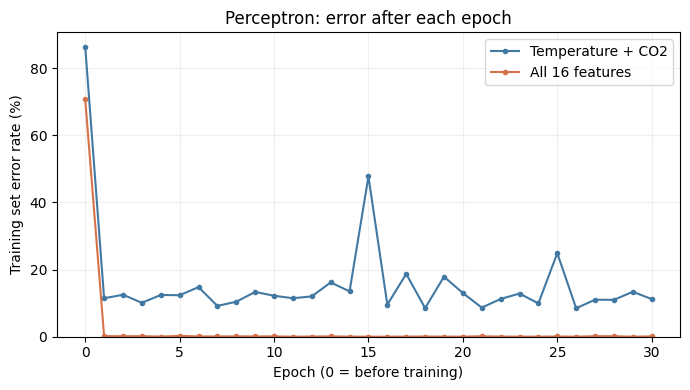

In [143]:
plt.figure(figsize=(7, 4))
for model, name, color in [(ppn, "Temperature + CO2", COLORS[0]),
                           (ppn_all, "All 16 features", COLORS[1])]:
    plt.plot(range(len(model.error_rates_)), np.array(model.error_rates_) * 100,
             marker="o", markersize=3, label=name, color=color)
plt.xlabel("Epoch (0 = before training)")
plt.ylabel("Training set error rate (%)")
plt.title("Perceptron: error after each epoch")
plt.ylim(bottom=0)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

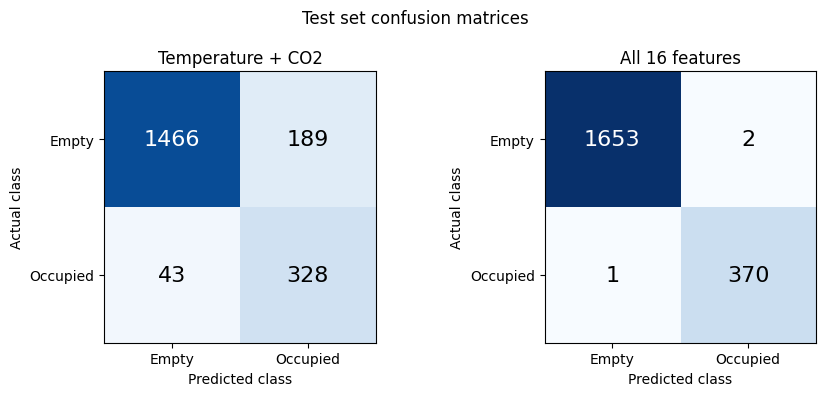

In [144]:
cm_all = np.zeros((2, 2), dtype=int)
np.add.at(cm_all, (y_test, y_pred_all), 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, matrix, name in zip(axes, [cm, cm_all],
                            ["Temperature + CO2", "All 16 features"]):
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(cm.max(), cm_all.max()))
    ax.set_xticks([0, 1], labels=["Empty", "Occupied"])
    ax.set_yticks([0, 1], labels=["Empty", "Occupied"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title(name)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > max(cm.max(), cm_all.max()) / 2 else "black",
                    fontsize=16)
fig.suptitle("Test set confusion matrices")
plt.tight_layout()
plt.show()